<a href="https://colab.research.google.com/github/3430-dotcom/KOAI/blob/main/OSHS__2026_share_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Height Prediction Program Using LSTM
---



##LSTM의 개념 및 원리

###**Concept**
---


긴 시계열 데이터나 문장에서 중요한 정보는 오래 기억하고, 불필요한 정보는 잊어버리도록 설계된 인공신경망



###**Principles**

---
LSTM은 셀 상태라는 흐름을 중심으로, 세 가지 게이트를 통해 정보를 조절한다.

* 망각 게이트 (Forget Gate): 이전 정보 중에서 얼마나 버릴지를 결정
* 입력 게이트 (Input Gate): 현재 들어온 정보 중에서 무엇을 새로 저장할지 결정
* 출력 게이트 (Output Gate): 지금까지의 정보를 바탕으로 어떤 값을 출력할지 결정

이 과정에서 중요한 정보는 셀 상태에 계속 더해지고 유지되며, 불필요한 정보는 게이트를 통해 제거된다.



##LSTM을 활용한 키 예측 프로그램 만들기


#### Preprocessing [데이터셋 전처리]

▶ pandas 라이브러리를 이용하여 원본 시계열 데이터(train_data.csv)를 모델 학습에 적합한 형태로 전처리한다.

* 0.5개월 단위로 기록된 데이터를 6개월 단위로 구간화 (binning)하여 시간 간격을 통일
* 동일한 사람(person_id), 성별(gender), 시간 구간(age_group)별로 데이터를 묶고, 키(height_cm)의 평균값으로 집계
* 집계된 데이터를 시간 흐름에 맞게 person_id와 age 기준으로 정렬
* 전처리된 결과를 새로운 CSV 파일로 저장

#####[CODE1]

In [ ]:
import pandas as pd

raw_df: pd.DataFrame = pd.read_csv('train_data.csv')

raw_df['age_group'] = (raw_df['age_months'] // 6) * 6

aggregated_df = raw_df.groupby(['person_id', 'gender', 'age_group'])['height_cm'].mean().reset_index()
aggregated_df = aggregated_df.rename(columns={'age_group': 'age_months'})
aggregated_df = aggregated_df.sort_values(by=['person_id', 'age_months']).reset_index(drop=True)

# save as csv
save_path = 'train_6m_aggregated.csv'
aggregated_df.to_csv(save_path, index=False, encoding='utf-8-sig')

print("저장되었습니다.")

저장되었습니다.


####LSTM 모델 훈련
▶ tensorflow 라이브러리 이용해서 LSTM 모델 훈련하기

#####[CODE2]

In [ ]:
!pip install -qqq tensorflow

# Third-party libraries
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler

# TensorFlow / Keras
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input

df: pd.DataFrame = pd.read_csv('train_6m_aggregated.csv')
df = df.sort_values(by=['person_id', 'age_months'])

df['delta_cm'] = df.groupby('person_id')['height_cm'].diff().shift(-1)

# 결측치(값이 비어있는 데이터 NaN) 제거
df = df.dropna()
df['delta_cm'] = df['delta_cm'].clip(lower=0)

# Min Max Normalization
df_scaled: pd.DataFrame = df.copy()

scaler_x: MinMaxScaler = MinMaxScaler()
features = ['age_months', 'gender', 'height_cm']
df_scaled[features] = scaler_x.fit_transform(df[features])

# Scaling
max_delta: float = df['delta_cm'].max()
df_scaled['target_delta'] = df['delta_cm'] / max_delta

# Build time-series sequences for LSTM training
seq_length: int = 5 # Quiz 1 (fill the blank)

X: list = []
y: list = []

grouped: pd.core.groupby.generic.DataFrameGroupBy = df_scaled.groupby('person_id')

for person, group in grouped:
    person_data = group[features].values
    person_target = group['target_delta'].values

    if len(person_data) < seq_length: continue

    for i in range(len(person_data) - seq_length + 1):
        X.append(person_data[i : i + seq_length])       # 과거 5개의 [개월, 성별, 키]
        y.append(person_target[i + seq_length - 1])     # 5번째 시점 직후의 6개월간 성장 폭

X = np.array(X)
y = np.array(y)

# 모델 구축
model = Sequential([
    # reLU 함수 이용해 키 줄어드는 현상 제거
    LSTM(32, activation='relu', return_sequences=False, input_shape=(X.shape[1], X.shape[2])),
    #Dropout(0.1),
    Dense(16, activation='relu'),
    Dense(1, activation='relu')
])

# Compile
custom_adam = Adam(learning_rate=0.0005) # Optimization
model.compile(optimizer=custom_adam, loss='mse', metrics=['mae'])

# 조기 종료 규칙
early_stop = EarlyStopping(
    monitor ='val_loss',        # validation 손실 감시
    patience = 10,              # 10 에포크 참기
    restore_best_weights = True # 복구
)

# 모델 훈련
print("LSTM 모델을 훈련 중 입니다...\n")
history = model.fit(
    X, y,
    epochs = 100,               # 최대 반복 횟수를 100으로 설정
    batch_size = 32,
    validation_split = 0.2,
    verbose = 1,
    callbacks = [early_stop]    # 조기 종료 규칙 적용
)
print("\nLSTM 모델이 훈련되었습니다.")


LSTM 모델을 훈련 중 입니다...

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0194 - mae: 0.0986 - val_loss: 0.0210 - val_mae: 0.1014
Epoch 2/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0021 - mae: 0.0308 - val_loss: 0.0011 - val_mae: 0.0254
Epoch 3/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 7.3214e-04 - mae: 0.0208 - val_loss: 5.4030e-04 - val_mae: 0.0182
Epoch 4/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4.3604e-04 - mae: 0.0163 - val_loss: 3.6557e-04 - val_mae: 0.0147
Epoch 5/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.1804e-04 - mae: 0.0138 - val_loss: 3.7424e-04 - val_mae: 0.0151
Epoch 6/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.9413e-04 - mae: 0.0133 - val_loss: 2.9270e-04 - val_mae: 0.0134
Epoch 7/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.9111e-04 - mae: 0.0132 - val_loss: 2.6900e-04 - val_mae: 0.0128
Epoch 8/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2.8791e-04 - mae: 0.0131 - val_loss: 2.6022e-04 - val_mae: 0.0126
Epoch 9/100




---


####LSTM 모델 훈련 과정 그래프
▶ mathplotlib 라이브러리를 활용해 LSTM 모델 훈련 과정을 그래프화하여 분석하기

#####[CODE3]

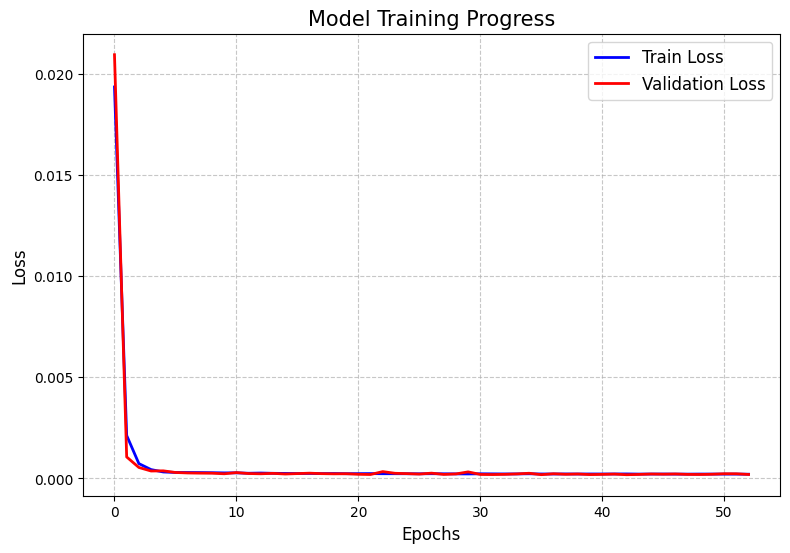

In [ ]:
import matplotlib.pyplot as plt

# 1. 그래프 크기 설정
plt.figure(figsize=(9, 6))

# 2. 훈련 데이터의 오차 선
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)

# 3. 검증 데이터의 오차 선
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)

# 4. 그래프 꾸밈
plt.title('Model Training Progress', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 5. 화면에 출력
plt.show()

▶ 결과 해석

tain_loss는 epochs가 증가함에 따라 당연히 0에 수렴하는 꼴이다

val_loss는 훈련이 잘되고있는지 검증하는 값으로 train_loss를 따라 감소하는 것이 훈련이 잘되고 있다는 뜻이다.



---


####LSTM 모델을 활용한 키 예측
▶ 훈련한 LSTM 모델을 활용하여 샘플 데이터 또는 본인의 키를 예측하기

16살 : 192개월

**샘플 데이터**

샘플 ①

    14세 ~ 16세 남성 : [168.0, 1, 165.3] [174.0, 1, 167.1] [180.0, 1, 169.6] [186.0, 1, 171.8] [192, 1, 172.6]

    16.5세 남성 평균 키 : 약 173cm ~ 175cm
  
샘플 ②
    
    14세 ~ 16세 여성 : [168.0, 0, 158.5] [174.0, 0, 159.2] [180.0, 0, 159.4] [186.0, 0, 159.8] [192, 0, 160.7]

    16.5세 여성 평균 키 : 약 161cm ~ 162cm

#####[CODE4]

In [ ]:
import numpy as np
import pandas as pd

# 데이터 입력

# [ , , ]               # 빈칸에 들어갈 내용을 보기에서 골라보세요.

# 과거에서 현재 순으로, 6개월 간격의 데이터 5개를 입력
my_data = [
    [168.0, 1, 165.3],  # 2년 전
    [174.0, 1, 167.1],  # 1년 6개월 전
    [180.0, 1, 169.6],  # 1년 전
    [186.0, 1, 171.8],  # 6개월 전
    [192, 1, 172.6]   # 현재
]

# 성별 확인
genders = [row[1] for row in my_data]
unique_genders = set(genders)

if len(unique_genders) != 1:
  raise ValueError("not continuous gender")

gender = unique_genders.pop()

if gender not in [0, 1]:
  raise ValueError("undefined gender")

my_gender = "여성" if gender == 0 else "남성"

#자기회귀 방식 사용하여 36개월(3년) 뒤 키 예측하기
loop_count = 6
current_data = my_data.copy()

for i in range(loop_count):
    recent_5_data = current_data[-5:]

    temp_df = pd.DataFrame(recent_5_data, columns=['age_months', 'gender', 'height_cm'])
    temp_scaled = scaler_x.transform(temp_df)
    temp_input = temp_scaled.reshape(1, 5, 3)

    predicted_scaled_delta = model.predict(temp_input, verbose=0)[0][0]
    predicted_delta_cm = predicted_scaled_delta * max_delta

    last_age = recent_5_data[-1][0]
    last_gender = recent_5_data[-1][1]
    last_height = recent_5_data[-1][2]

    next_age = last_age + 6.0
    next_height = last_height + predicted_delta_cm

    current_data.append([next_age, last_gender, next_height])

    print(f"{(i+1)*6}개월 뒤 ({next_age}개월) 예상 키: {next_height:.1f} cm (성장폭: +{predicted_delta_cm:.2f} cm)")

# 최종 결과 출력
final_age = current_data[-1][0]
final_height = current_data[-1][2]
print(f"\n3년 뒤({final_age}개월) 최종 예측 키 : {final_height:.2f} cm")

6개월 뒤 (198.0개월) 예상 키: 172.8 cm (성장폭: +0.19 cm)
12개월 뒤 (204.0개월) 예상 키: 172.9 cm (성장폭: +0.14 cm)
18개월 뒤 (210.0개월) 예상 키: 173.1 cm (성장폭: +0.12 cm)
24개월 뒤 (216.0개월) 예상 키: 173.2 cm (성장폭: +0.10 cm)
30개월 뒤 (222.0개월) 예상 키: 173.3 cm (성장폭: +0.10 cm)
36개월 뒤 (228.0개월) 예상 키: 173.4 cm (성장폭: +0.10 cm)

3년 뒤(228.0개월) 최종 예측 키 : 173.36 cm
